In [1]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense,LSTM
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
max_features = 10000 #vocabulary size (only top 10,000 words are used)
max_len =200 #Max length of a sequence(Reviews are padded or turncated to 200 words)

(x_train,Y_train),(x_test,y_test) = imdb.load_data(num_words=max_features)
#Pad sequences to ensure all inputs are the same length
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [3]:
sample_review = x_train[0]
print(sample_review)

[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113  103   32   15   16
 5345 

In [23]:
word_index = imdb.get_word_index()

# Reverse mapping
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in review])

sample_review = x_train[0]
decoded_review = decode_review(sample_review)

print(f"Sample review (as integers):\n{sample_review}\n")
print(f"Sample review (decoded):\n{decoded_review}\n")
print(f"Sentiment: {'Positive' if Y_train[0] == 1 else 'Negative'}")

Sample review (as integers):
[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  1

In [24]:
def decode_review(review):
    return ' '.join([
        '<PAD>' if i == 0 else
        '<START>' if i == 1 else
        '<UNK>' if i == 2 else
        reverse_word_index.get(i - 3, '?')
        for i in review
    ])

In [5]:
#model = Sequential()
#Embedding layer: Convert word indices into Embeddings 
#model.add(Embedding(input_dim=max_features,output_dim=128,input_length=max_len ))
#RNNLayer: Add a SimpleRNN layer with 128 units
#model.add(SimpleRNN(100,return_sequences=False))
#Add Droput for regularization
#model.add(Dropout(0.2))
#Fully Connected Layer with sigmoid activation for binary classification
#model.add(Dense(1,activation='sigmoid'))
#Compile the model
#model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
model = Sequential()
model.add(Embedding(input_dim=max_features,output_dim=128,input_length=max_len ))
model.add(LSTM(100,return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

In [29]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
#train model
history = model.fit(x_train, Y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 77s 192ms/step - accuracy: 0.7972 - loss: 0.4332 - val_accuracy: 0.8549 - val_loss: 0.3465
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.8931 - loss: 0.2691 - val_accuracy: 0.8192 - val_loss: 0.3981
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 203ms/step - accuracy: 0.9252 - loss: 0.1966 - val_accuracy: 0.8527 - val_loss: 0.3949
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 204ms/step - accuracy: 0.9477 - loss: 0.1418 - val_accuracy: 0.8607 - val_loss: 0.3827
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 193ms/step - accuracy: 0.9618 - loss: 0.1064 - val_accuracy: 0.8564 - val_loss: 0.4665


In [19]:
#Evaluate The Model
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f'Test Accuracy:{test_acc}')

782/782 - 22s - 28ms/step - accuracy: 0.8564 - loss: 0.4665
Test Accuracy:0.8563600182533264


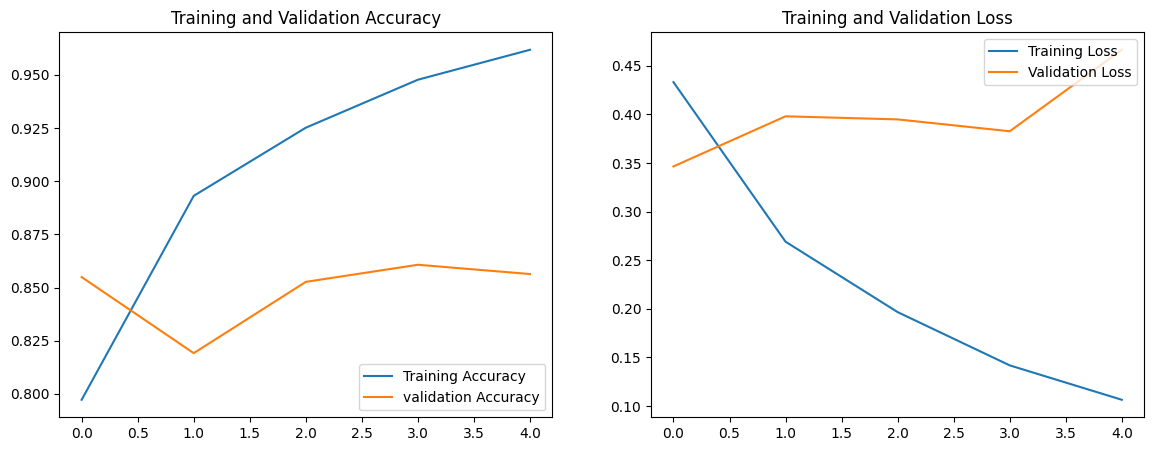

In [20]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./LSTM.png')
plt.show()
